# Spyglass Tutorial — Pagan Lab arc_ecephys

This notebook demonstrates how to access Pagan Lab data that has been
converted to NWB and inserted into a Spyglass database.

Two example sessions are covered:
- **P100** (`sub-P100_ses-TaskSwitch4-181010a`) — tetrode electrophysiology + BControl behavior + processed trials
- **P267** (`sub-P267_ses-TaskSwitch6-221211a`) — behavioral video + BControl behavior

Contents:
1. [Connect to the Spyglass database](#1.-Setup)
2. [Core Spyglass tables](#2.-Core-Spyglass-Tables)
3. [Task epochs and interval lists](#3.-Task-Epochs-and-Interval-Lists)
4. [Electrode and probe geometry (P100)](#4.-Electrode-and-Probe-Geometry-(P100))
5. [Video file reference (P267)](#5.-Video-File-(P267))
6. [BControl task metadata](#6.-BControl-Task-Metadata)
7. [Behavioral data](#7.-Behavioral-Data)
8. [Spike-sorted units (P100)](#8.-Spike-Sorted-Units-(P100))
9. [PSTH data (P100)](#9.-PSTH-Data-(TimeSeries (rrr4_psth)))
10. [Processed trials — ProcessedTrialsInterface (P100)](#10.-Processed-Trials-—-ProcessedTrialsInterface-(P100))

## 1. Setup

In [1]:
import warnings
from pathlib import Path

import datajoint as dj
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)

# Load DataJoint config — MUST be done before importing spyglass
DJ_LOCAL_CONF_PATH = Path("../arc_ecephys/dj_local_conf.json")
dj.config.load(str(DJ_LOCAL_CONF_PATH))
dj.conn(use_tls=False)

import ndx_franklab_novela  # required for custom NWB type resolution
import spyglass.common as sgc
from spyglass.common.common_task import TaskEpoch
from spyglass.common.common_task_rec import TaskRecording, TaskRecordingTypes
from spyglass.settings import raw_dir
from spyglass.utils.nwb_helper_fn import get_nwb_copy_filename, get_nwb_file

SPYGLASS_RAW_DIR = Path(raw_dir)
print(f"Connected to Spyglass database \u2713")
print(f"Raw dir: {SPYGLASS_RAW_DIR}")

/Users/weian/anaconda3/envs/spyglass_env_py312/lib/python3.12/site-packages/datajoint/plugin.py:4: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources  # requires setuptools<82
[2026-04-27 16:27:19,422][INFO]: DataJoint is configured from /Users/weian/catalystneuro/pagan-lab-to-nwb/src/pagan_lab_to_nwb/arc_ecephys/dj_local_conf.json
[2026-04-27 16:27:19,431][INFO]: DataJoint 0.14.9 connected to root@localhost:3306
[16:27:19][WARNING] Spyglass: Setting config DJ stores to resolve mismatch.
	raw     : /Volumes/T9/data/Pagan/raw
	analysis: /Volumes/T9/data/Pagan/analysis


Connected to Spyglass database ✓
Raw dir: /Volumes/T9/data/Pagan/raw


## 2. Core Spyglass Tables

When a session is inserted, Spyglass creates a copy of the NWB file with a
`_` suffix appended to the filename (e.g. `sub-P100_ses-..._` .nwb`). All
Spyglass table queries use this copy filename as the primary key.

In [2]:
# Session identifiers
EPHYS_NWB = "sub-P100_ses-TaskSwitch4-181010a.nwb"   # ephys + behavior
VIDEO_NWB = "sub-P267_ses-TaskSwitch6-221211a.nwb"   # video + behavior

ephys_copy = get_nwb_copy_filename(EPHYS_NWB)
video_copy = get_nwb_copy_filename(VIDEO_NWB)

ephys_dict = {"nwb_file_name": ephys_copy}
video_dict = {"nwb_file_name": video_copy}

print(f"Ephys session copy:  {ephys_copy}")
print(f"Video session copy:  {video_copy}")

Ephys session copy:  sub-P100_ses-TaskSwitch4-181010a_.nwb
Video session copy:  sub-P267_ses-TaskSwitch6-221211a_.nwb


### Nwbfile

In [3]:
# Nwbfile — one row per inserted session
nwbfile_entries = (sgc.Nwbfile() & [ephys_dict, video_dict]).fetch(as_dict=True)
pd.DataFrame(nwbfile_entries)[["nwb_file_name", "nwb_file_abs_path"]]

,nwb_file_name,nwb_file_abs_path
0,sub-P100_ses-TaskSwitch4-181010a_.nwb,/Volumes/T9/data/Pagan/raw/sub-P100_ses-TaskSw...
1,sub-P267_ses-TaskSwitch6-221211a_.nwb,/Volumes/T9/data/Pagan/raw/sub-P267_ses-TaskSw...


### Session

In [4]:
# Session — core recording metadata
sessions_df = pd.DataFrame(
    (sgc.Session() & [ephys_dict, video_dict]).fetch(as_dict=True)
)
sessions_df[
    ["nwb_file_name", "subject_id", "session_id", "institution_name", "lab_name"]
].fillna("")

,nwb_file_name,subject_id,session_id,institution_name,lab_name
0,sub-P100_ses-TaskSwitch4-181010a_.nwb,P100,TaskSwitch4-181010a,University of Edinburgh,Pagan
1,sub-P267_ses-TaskSwitch6-221211a_.nwb,P267,TaskSwitch6-221211a,University of Edinburgh,Pagan


In [5]:
# Session.Experimenter — linked experimenters
exp_df = pd.DataFrame(
    (sgc.Session.Experimenter() & [ephys_dict, video_dict]).fetch(as_dict=True)
)
exp_df

""


### Subject

In [6]:
# Subject — keyed by subject_id (not nwb_file_name)
subject_ids = (sgc.Session() & [ephys_dict, video_dict]).fetch("subject_id")
subjects_df = pd.DataFrame(
    (sgc.Subject() & [{"subject_id": s} for s in subject_ids]).fetch(as_dict=True)
)
subjects_df

,subject_id,age,description,genotype,sex,species
0,P100,None,None,None,M,Rattus norvegicus
1,P267,None,None,None,M,Rattus norvegicus


### Lab, Institution, and LabMember

In [7]:
# Lab and Institution
print("Lab:")
display(pd.DataFrame(sgc.Lab.fetch(as_dict=True)))

print("\nInstitution:")
display(pd.DataFrame(sgc.Institution.fetch(as_dict=True)))

print("\nLabMember:")
display(pd.DataFrame(sgc.LabMember.fetch(as_dict=True)))

Lab:


,lab_name
0,Pagan
1,Pagan Lab



Institution:


,institution_name
0,University of Edinburgh



LabMember:


,lab_member_name,first_name,last_name
0,Marino Pagan,Marino,Pagan
1,Vincent D. Tang,Vincent D.,Tang


## 3. Task Epochs and Interval Lists

`TaskEpoch` records the task name and recording environment for each epoch.
`IntervalList` stores the valid time windows within each epoch.

In [8]:
# TaskEpoch — one epoch per session
epochs_df = pd.DataFrame(
    (TaskEpoch() & [ephys_dict, video_dict]).fetch(as_dict=True)
)
epochs_df[
    ["nwb_file_name", "epoch", "task_name", "interval_list_name", "task_environment"]
].fillna("")

,nwb_file_name,epoch,task_name,interval_list_name,task_environment
0,sub-P100_ses-TaskSwitch4-181010a_.nwb,1,TaskSwitch4,01,behavioral_box
1,sub-P267_ses-TaskSwitch6-221211a_.nwb,1,TaskSwitch6,01,behavioral_box


In [9]:
# IntervalList — valid recording intervals for each session
for nwb_dict in [ephys_dict, video_dict]:
    rows = (sgc.IntervalList() & nwb_dict).fetch(as_dict=True)
    for row in rows:
        iv = row["valid_times"]
        start, stop = float(iv[0, 0]), float(iv[-1, 1])
        print(
            f"{row['nwb_file_name']}: '{row['interval_list_name']}'"
            f"  {start:.1f} \u2013 {stop:.1f} s  ({stop-start:.1f} s)"
        )

sub-P100_ses-TaskSwitch4-181010a_.nwb: '01'  0.0 – 6522.6 s  (6522.6 s)
sub-P267_ses-TaskSwitch6-221211a_.nwb: '01'  0.0 – 8048.9 s  (8048.9 s)


## 4. Electrode and Probe Geometry (P100)

The P100 session used a 32-tetrode SpikeGadgets array (128 channels total).
Spyglass stores device metadata in `DataAcquisitionDevice` and `ProbeType`,
and per-session electrode information in `ElectrodeGroup` and `Electrode`.

In [10]:
# DataAcquisitionDevice — recording system
pd.DataFrame(sgc.DataAcquisitionDevice.fetch(as_dict=True))

,data_acquisition_device_name,data_acquisition_device_system,data_acquisition_device_amplifier,adc_circuit
0,HH128,SpikeGadgets,Horizontal Headstage 128-Channel Datalogger,Horizontal Headstage 128-Channel Datalogger


In [11]:
# ProbeType — probe geometry metadata
pd.DataFrame(sgc.ProbeType.fetch(as_dict=True))

,probe_type,probe_description,manufacturer,num_shanks
0,tetrode,"32-tetrode array (SpikeGadgets, Pagan Lab)",,1


In [12]:
# ElectrodeGroup — one group per tetrode (32 total)
eg_df = pd.DataFrame(
    (sgc.ElectrodeGroup() & ephys_dict).fetch(as_dict=True)
)
print(f"{len(eg_df)} electrode groups")
eg_df[["electrode_group_name", "probe_id", "region_id", "description"]].head(10)

32 electrode groups


,electrode_group_name,probe_id,region_id,description
0,tetrode1,tetrode,1,Tetrode 1
1,tetrode10,tetrode,1,Tetrode 10
2,tetrode11,tetrode,1,Tetrode 11
3,tetrode12,tetrode,1,Tetrode 12
4,tetrode13,tetrode,1,Tetrode 13
5,tetrode14,tetrode,1,Tetrode 14
6,tetrode15,tetrode,1,Tetrode 15
7,tetrode16,tetrode,1,Tetrode 16
8,tetrode17,tetrode,1,Tetrode 17
9,tetrode18,tetrode,1,Tetrode 18


In [13]:
# Electrode — 4 channels per tetrode, 128 total
# probe_shank=0 (single shank), probe_electrode=0..3 (4 wires per tetrode)
elec_df = pd.DataFrame(
    (sgc.Electrode() & ephys_dict).fetch(as_dict=True)
)
print(f"{len(elec_df)} electrodes total")
elec_df[
    ["electrode_id", "electrode_group_name", "probe_shank", "probe_electrode",
     "bad_channel", "original_reference_electrode"]
].head(12)

128 electrodes total


,electrode_id,electrode_group_name,probe_shank,probe_electrode,bad_channel,original_reference_electrode
0,0,tetrode1,0,0,False,-1
1,1,tetrode1,0,1,False,-1
2,2,tetrode1,0,2,False,-1
3,3,tetrode1,0,3,False,-1
4,36,tetrode10,0,0,False,-1
5,37,tetrode10,0,1,False,-1
6,38,tetrode10,0,2,False,-1
7,39,tetrode10,0,3,False,-1
8,40,tetrode11,0,0,False,-1
9,41,tetrode11,0,1,False,-1


## 5. Video File (P267)

The P267 session has an overhead camera recording. Spyglass stores a reference
to the external MP4 file in `VideoFile` and camera properties in `CameraDevice`.

In [14]:
# VideoFile — references the ImageSeries in the NWB copy
video_rows = (sgc.VideoFile() & video_dict).fetch(as_dict=True)
pd.DataFrame(video_rows)

,nwb_file_name,epoch,video_file_num,camera_name,video_file_object_id
0,sub-P267_ses-TaskSwitch6-221211a_.nwb,1,1,top_camera,4f545469-5b58-4521-b7a6-00e5a512cae8


In [15]:
# Retrieve the actual video file path from the NWB copy
nwb_copy_path = SPYGLASS_RAW_DIR / video_copy
nwbf = get_nwb_file(str(nwb_copy_path))
behavior_mod = nwbf.processing.get("behavior")
if behavior_mod:
    video_iface = behavior_mod.data_interfaces.get("video")
    if video_iface:
        img_series = list(video_iface.time_series.values())[0]
        print(f"Video file path: {img_series.external_file[0]}")

Video file path: /Volumes/T9/data/Video_data_examples/video_@TaskSwitch6_Marino_P267_221211a.mp4


In [16]:
# CameraDevice — camera properties
pd.DataFrame((sgc.CameraDevice() & {"camera_id": 1}).fetch(as_dict=True))

,camera_name,meters_per_pixel,manufacturer,model,lens,camera_id
0,top_camera,0.001,,,unknown,1


## 6. BControl Task Metadata

`TaskRecordingTypes` stores the vocabulary of the behavioral task:
- **StateTypes** — finite-state-machine states (wait, cpoke, hit, error, …)
- **EventTypes** — nose-poke port events (C=center, L=left, R=right)
- **ActionTypes** — reward deliveries and timer actions
- **Arguments** — session-level protocol parameters and performance statistics

Both sessions follow the same table structure; we query P100 (TaskSwitch4) here.

In [17]:
# State types — FSM states
state_types_df = pd.DataFrame(
    (TaskRecordingTypes.StateTypes() & ephys_dict).fetch(as_dict=True)
).set_index("id")
print(f"{len(state_types_df)} state types")
state_types_df[["state_name"]]

21 state types


,state_name
id,
0,state_0
1,sending_trialnum
2,check_next_trial_ready
3,wait_for_cpoke
4,wait_for_cpoke1
5,wait_for_cpoke_dir
6,wait_for_cpoke_freq
7,wait_for_cpoke_bis
8,nic_prestim


In [18]:
# Event types — port events
event_types_df = pd.DataFrame(
    (TaskRecordingTypes.EventTypes() & ephys_dict).fetch(as_dict=True)
).set_index("id")
event_types_df[["event_name"]]

,event_name
id,
0,C
1,L
2,R


In [19]:
# Action types — reward and timer actions
action_types_df = pd.DataFrame(
    (TaskRecordingTypes.ActionTypes() & ephys_dict).fetch(as_dict=True)
).set_index("id")
action_types_df[["action_name"]]

,action_name
id,
0,direct_reward
1,cpoke_timer


In [20]:
# Session-level arguments (protocol parameters + performance stats)
args_df = pd.DataFrame(
    (TaskRecordingTypes.Arguments() & ephys_dict).fetch(as_dict=True)
)
print(f"Total arguments: {len(args_df)}")
# Show scalar (non-array) arguments
scalar_args = args_df[args_df["output_type"] != "numeric"].copy()
scalar_args[["argument_name", "expression"]].head(20)

Total arguments: 162


,argument_name,expression
7,HistorySection_last_result,timeout viol
12,HistorySection_previous_stage,Stage 10
13,HistorySection_previous_task,Direction
16,HistorySection_title,HistorySection
28,SavingSection_data_file,C:\ratter\SoloData\Data\Marino\P100\data_@Task...
29,SavingSection_experimenter,Marino
30,SavingSection_hostname,brodyrig08.Princeton.EDU
33,SavingSection_ratname,P100
34,SavingSection_SaveTime,10-Oct-2018 12:36:30
37,SavingSection_title,SavingSection


## 7. Behavioral Data

`TaskRecording` stores NWB object references for the behavioral time-series.
`fetch1_dataframe("events"|"states"|"actions"|"trials")` reads directly from
the `_.nwb` copy file on disk.

In [21]:
TaskRecording()

nwb_file_name name of the NWB file,actions_object_id,events_object_id,states_object_id,trials_object_id
sub-H7015_ses-250516a-spyglass_.nwb,bb38d4c7-58bc-4c5c-ab9d-e88288953d34,4ffe2b8f-18a3-4751-bf8f-e46090163517,1cc869ca-b28f-44e5-871b-31523e8962f4,1cac2baa-2741-4fe4-9176-61bcb56d1e55
sub-H7015_ses-250516a-test_.nwb,0c515f11-6bfa-416e-99a0-a57287ad31de,4f880735-b56e-4bfc-8866-f3537c90c611,85339040-7091-408f-b62f-af23c0929398,98d32e06-d075-45f1-af72-fb856056809f
sub-H7015_ses-250516a10.nwb,d9dc96f5-66e5-42c8-8dab-01370497717e,0e6aef07-c4a1-4b7a-9ae8-68425d5f92de,949d73b7-1d8f-48a1-bd32-dd5138b362ad,08da9ff7-a6c2-4948-ab36-ded4e0224e7b
sub-P100_ses-TaskSwitch4-180110a_.nwb,35cfb91e-b776-4783-8bd7-a7c7907403df,b950bf7f-64f9-434f-8bd9-ad82eece9aa4,92120105-26fc-4609-be69-e05dca9f14fa,38a7ecba-75ca-43f1-b4e5-e8a51cfd7c29
sub-P100_ses-TaskSwitch4-181010a_.nwb,55410fe7-83be-448f-af93-8698256c36d2,82389970-ce46-4356-a679-f8b4f79cbe54,79d47e6a-06e3-4f77-af1e-f39fb566419e,6de766f1-a94b-4aad-bf50-e0600c7552bd
sub-P131_ses-TaskSwitch6-190815a_.nwb,f8dcd5da-4008-439b-93ca-501a8a16db35,17b77ca1-44e2-4291-8ea5-bcebfcbe6da5,f6005b13-8cc6-46da-86c3-e69dfb779a9d,b9bc29fe-a111-404a-a780-cbdef20e0ab0
sub-P267_ses-TaskSwitch6-221211a_.nwb,37d7a0b9-7bec-49f6-b7ef-fe2a0ba2271a,0e5d4927-26c5-4982-9de9-e4adbf810822,db3cb04a-0e14-44a1-b08a-09b4564759c5,24782904-21c6-4474-897d-8984b4a07734


In [22]:
(TaskRecording() & ephys_dict)

nwb_file_name name of the NWB file,actions_object_id,events_object_id,states_object_id,trials_object_id
sub-P100_ses-TaskSwitch4-181010a_.nwb,55410fe7-83be-448f-af93-8698256c36d2,82389970-ce46-4356-a679-f8b4f79cbe54,79d47e6a-06e3-4f77-af1e-f39fb566419e,6de766f1-a94b-4aad-bf50-e0600c7552bd


In [23]:
# Events — nose-poke port entries and exits
events_df = (TaskRecording() & ephys_dict).fetch1_dataframe("events")
events_df["event_type"] = events_df["event_type"].apply(lambda x: x.values[0][0])
print(f"{len(events_df)} nose-poke events")
print(events_df["event_type"].value_counts().to_dict())
events_df.head()

9448 nose-poke events
{'R': 3957, 'L': 2841, 'C': 2650}


,timestamp,event_type,value,duration
id,,,,
0,77.756327,R,out,0.190503
1,83.277827,L,out,0.187500
2,84.124831,L,out,0.044996
3,84.253832,L,out,0.051495
4,84.387827,L,out,0.048000


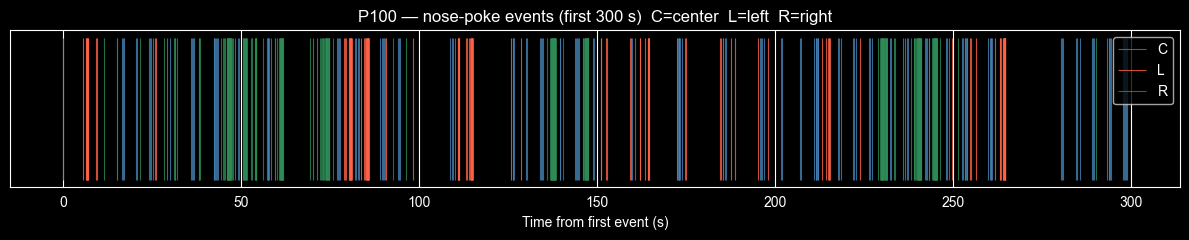

In [24]:
# Color-coded nose-poke event raster (first 300 s)
event_colors = {"C": "steelblue", "L": "tomato", "R": "seagreen"}
t0 = events_df["timestamp"].min()
window_events = events_df[events_df["timestamp"] - t0 < 300].copy()

fig, ax = plt.subplots(figsize=(12, 2.5))
for etype, grp in window_events.groupby("event_type"):
    ax.vlines(
        grp["timestamp"] - t0,
        ymin=0, ymax=1,
        color=event_colors.get(etype, "gray"),
        lw=0.8, alpha=0.8,
        label=etype,
    )
ax.set_xlabel("Time from first event (s)")
ax.set_yticks([])
ax.set_title("P100 \u2014 nose-poke events (first 300 s)  C=center  L=left  R=right")
ax.legend(loc="upper right")
fig.tight_layout()
plt.show()

In [25]:
# Actions — reward deliveries and timer resets
actions_df = (TaskRecording() & ephys_dict).fetch1_dataframe("actions")
actions_df["action_type"] = actions_df["action_type"].apply(lambda x: x.values[0][0])
print(f"{len(actions_df)} action events")
print(actions_df["action_type"].value_counts().to_dict())
actions_df.head()

1153 action events
{'cpoke_timer': 771, 'direct_reward': 382}


,timestamp,action_type,value,duration
id,,,,
0,95.703327,cpoke_timer,out,0.0
1,99.754838,cpoke_timer,out,0.0
2,103.506327,cpoke_timer,out,0.0
3,108.328837,cpoke_timer,out,0.0
4,115.065327,cpoke_timer,out,0.0


In [26]:
# States — FSM state transitions
states_df = (TaskRecording() & ephys_dict).fetch1_dataframe("states")
states_df["state_type"] = states_df["state_type"].apply(lambda x: x.values[0][0])
print(f"{len(states_df)} state transitions")
print(states_df["state_type"].value_counts().head(8).to_dict())
states_df.head()

13795 state transitions
{'cpoke_in': 2324, 'cpoke_out': 2011, 'wait_for_cpoke': 782, 'wait_for_cpoke1': 782, 'wait_for_cpoke_bis': 782, 'clean_up_state': 780, 'sending_trialnum': 780, 'state_0': 780}


,start_time,stop_time,state_type
id,,,
0,77.591827,97.481327,state_0
1,77.591827,77.607827,sending_trialnum
2,77.607827,77.608327,wait_for_cpoke
3,77.608327,77.608844,wait_for_cpoke1
4,77.608844,78.109327,wait_for_cpoke_dir


In [27]:
# Trials — one row per trial with all task variables
trials_df = (TaskRecording() & ephys_dict).fetch1_dataframe("trials")
exclude_cols = {"states", "events", "actions"}
display_cols = [c for c in trials_df.columns if c not in exclude_cols]
print(f"{len(trials_df)} trials, {len(display_cols)} task variable columns")
trials_df[display_cols].head()

780 trials, 27 task variable columns


,start_time,stop_time,cpoke_start_time,left_hi,right_hi,left_lo,right_lo,crosstalk_dir,crosstalk_freq,bup_width,...,freq_lo,freq_hi,HistorySection_hit_history,HistorySection_side_history,HistorySection_quadrant_history,HistorySection_task_history,HistorySection_incoh_history,HistorySection_gammadir_history,HistorySection_gammafreq_history,HistorySection_result_history
id,,,,,,,,,,,,,,,,,,,,,
0,77.591827,97.481327,94.302841,[],[],"[0.405015, 0.50278, 1.246845]","[0.005635, 0.00992, 0.06467, 0.07482, 0.09019,...",0,0,5,...,6500,14200,NaN,r,1,d,1,2.5,-4.0,3
1,97.481827,101.560327,98.354332,[0.90884],[],"[0.011315, 0.032345, 0.081855, 0.08193, 0.1174...",[1.046015],0,0,5,...,6500,14200,NaN,l,2,d,0,-4.0,-2.5,3
2,101.560832,106.408327,102.106327,"[0.07143, 0.27127, 0.32291, 0.421915, 0.49351,...",[0.334115],"[0.19655, 0.209695, 0.27971, 0.27999, 0.30057,...","[0.87651, 0.91338]",0,0,5,...,6500,14200,NaN,l,2,d,0,-2.5,-1.0,3
3,106.408835,112.914835,106.928327,[],"[0.928085, 1.230135]","[0.004645, 0.130325, 0.163235, 0.207255, 0.255...","[0.068845, 0.35154, 0.4934, 0.62778, 0.812435,...",0,0,5,...,6500,14200,0.0,l,2,d,0,-1.0,-4.0,2
4,112.915328,119.793827,113.664846,"[0.36787, 0.426775]",[],"[0.00109, 0.05117, 0.073205, 0.08856, 0.1655, ...","[0.035655, 0.045535, 0.219055, 0.39606, 0.4567...",0,0,5,...,6500,14200,0.0,l,2,d,0,-1.0,-4.0,2


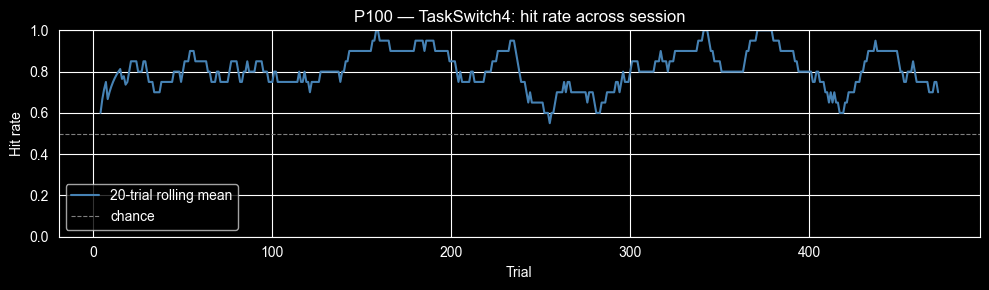

In [28]:
# Rolling hit rate across the session
hits = trials_df["HistorySection_hit_history"].dropna().astype(float)
window = 20
rolling_hr = hits.rolling(window, min_periods=5).mean()

fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(range(len(rolling_hr)), rolling_hr.values, lw=1.5, color="steelblue",
        label=f"{window}-trial rolling mean")
ax.axhline(0.5, color="gray", lw=0.8, ls="--", label="chance")
ax.set_xlabel("Trial")
ax.set_ylabel("Hit rate")
ax.set_title("P100 \u2014 TaskSwitch4: hit rate across session")
ax.legend()
ax.set_ylim(0, 1)
fig.tight_layout()
plt.show()

In [29]:
# Sub-events for a single trial
trial_idx = 5
print(f"Trial {trial_idx} \u2014 states:")
t_states = trials_df.states[trial_idx].copy()
t_states["state_type"] = t_states["state_type"].apply(lambda x: x.values[0][0])
print(t_states[["start_time", "stop_time", "state_type"]].to_string())

print(f"\nTrial {trial_idx} \u2014 events:")
t_events = trials_df.events[trial_idx].copy()
t_events["event_type"] = t_events["event_type"].apply(lambda x: x.values[0][0])
print(t_events[["timestamp", "event_type", "value"]].to_string())

Trial 5 — states:
    start_time   stop_time          state_type
id                                            
75  119.794327  122.611327             state_0
76  119.794327  119.810327    sending_trialnum
77  119.810327  119.810834      wait_for_cpoke
78  119.810834  119.811327     wait_for_cpoke1
79  119.811327  120.311827  wait_for_cpoke_dir
80  120.311827  120.312327  wait_for_cpoke_bis
81  120.312327  120.313827         nic_prestim
82  120.313827  120.314327               cpoke
83  120.314327  120.344838            cpoke_in
84  120.344838  120.363827           cpoke_out
85  120.363827  120.618327            cpoke_in
86  120.618327  120.688327           cpoke_out
87  120.688327  120.911327            cpoke_in
88  120.911327  120.936327           cpoke_out
89  120.936327  121.307327            cpoke_in
90  121.307327  121.322835           cpoke_out
91  121.322835  121.713827            cpoke_in
92  121.713827  121.792327       wait_for_cout
93  121.792327  122.155327      wait_for_s

## 8. Spike-Sorted Units (P100)

When a NWB file contains a `units` table, `sgi.insert_sessions()` automatically
populates `ImportedSpikeSorting` and `SpikeSortingOutput`.  `SortedSpikesGroup`
then provides a named group of units that downstream analysis tables can reference.

For P100, the spikes.mat file contains 641 spike-sorted units across 32 tetrodes.
Each unit is annotated with its `trode_id` (tetrode number, 1-indexed).

In [30]:
import spyglass.spikesorting.v1 as sgs
from spyglass.spikesorting.spikesorting_merge import SpikeSortingOutput
from spyglass.spikesorting.analysis.v1.group import SortedSpikesGroup
from spyglass.spikesorting.analysis.v1.unit_annotation import UnitAnnotation

# ImportedSpikeSorting — populated automatically by insert_sessions()
imp_sort = (sgs.ImportedSpikeSorting() & ephys_dict).fetch1()
print(f"ImportedSpikeSorting object_id: {imp_sort['object_id']}")

# SpikeSortingOutput — merge table unifying all sorting sources
merge_id = str(
    (SpikeSortingOutput.ImportedSpikeSorting() & ephys_dict).fetch1("merge_id")
)
print(f"merge_id: {merge_id}")

[16:27:35][INFO] Spyglass: Initializing UserEnvironment for spikesorting: root_spyglass_env_py312_03


ImportedSpikeSorting object_id: 76349471-cec0-4455-b2cf-3d251f829c0d
merge_id: 1c7ecb37-1f28-a11f-8478-cdf4205901ff


In [31]:
# SortedSpikesGroup — named group of all sorted units
group_key = (
    SortedSpikesGroup() & {**ephys_dict, "sorted_spikes_group_name": "all_units"}
).fetch1("KEY")
print("Group key:", group_key)

# Fetch spike trains — returns list of arrays, one per unit
spike_trains, unit_ids = SortedSpikesGroup().fetch_spike_data(
    group_key, return_unit_ids=True
)
print(f"\n{len(spike_trains)} units")
print(f"Unit 0: {len(spike_trains[0])} spikes,  first 5 times: {spike_trains[0][:5]}")

Group key: {'nwb_file_name': 'sub-P100_ses-TaskSwitch4-181010a_.nwb', 'unit_filter_params_name': 'all_units', 'sorted_spikes_group_name': 'all_units'}

641 units
Unit 0: 18 spikes,  first 5 times: [ 86.2879374  108.65282143 193.88397978 242.76885124 432.17249213]


In [32]:
# UnitAnnotation — trode_id for each unit
annot_df = pd.DataFrame(
    (UnitAnnotation.Annotation() & {"spikesorting_merge_id": merge_id}).fetch(as_dict=True)
)
print(f"{len(annot_df)} unit annotations")
annot_df.head()

466 unit annotations


,spikesorting_merge_id,unit_id,annotation,label,quantification
0,1c7ecb37-1f28-a11f-8478-cdf4205901ff,0,trode_id,None,1.0
1,1c7ecb37-1f28-a11f-8478-cdf4205901ff,1,trode_id,None,1.0
2,1c7ecb37-1f28-a11f-8478-cdf4205901ff,2,trode_id,None,1.0
3,1c7ecb37-1f28-a11f-8478-cdf4205901ff,3,trode_id,None,1.0
4,1c7ecb37-1f28-a11f-8478-cdf4205901ff,4,trode_id,None,1.0


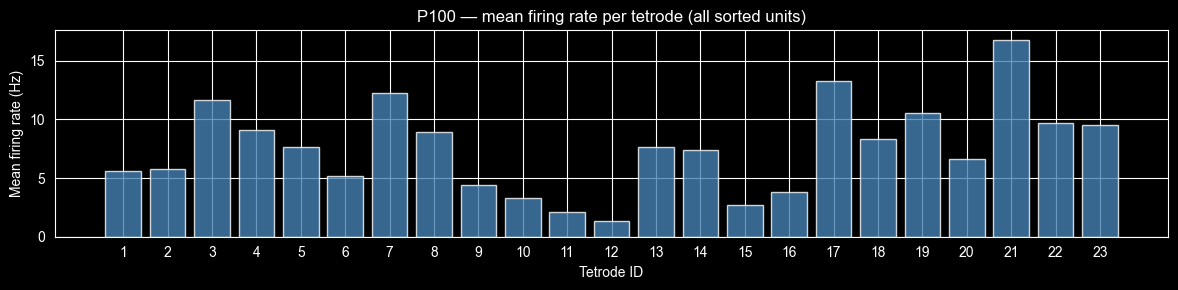


Total units: 466,  Session duration: 6459.0 s


In [33]:
# Mean firing rate per tetrode
all_spikes = [s for s in spike_trains if len(s) > 0]
session_dur = max(s[-1] for s in all_spikes) - min(s[0] for s in all_spikes)

trode_ids = annot_df.set_index("unit_id")["quantification"].astype(int)
rates = [
    len(spike_trains[uid]) / session_dur
    for uid in annot_df["unit_id"]
]
rate_df = pd.DataFrame({"trode_id": trode_ids.values, "firing_rate_hz": rates})
by_trode = rate_df.groupby("trode_id")["firing_rate_hz"].agg(["mean", "count"])

fig, ax = plt.subplots(figsize=(12, 3))
ax.bar(by_trode.index, by_trode["mean"], color="steelblue", alpha=0.8)
ax.set_xlabel("Tetrode ID")
ax.set_ylabel("Mean firing rate (Hz)")
ax.set_title("P100 \u2014 mean firing rate per tetrode (all sorted units)")
ax.set_xticks(by_trode.index)
fig.tight_layout()
plt.show()
print(f"\nTotal units: {len(rate_df)},  Session duration: {session_dur:.1f} s")

### Spike Raster

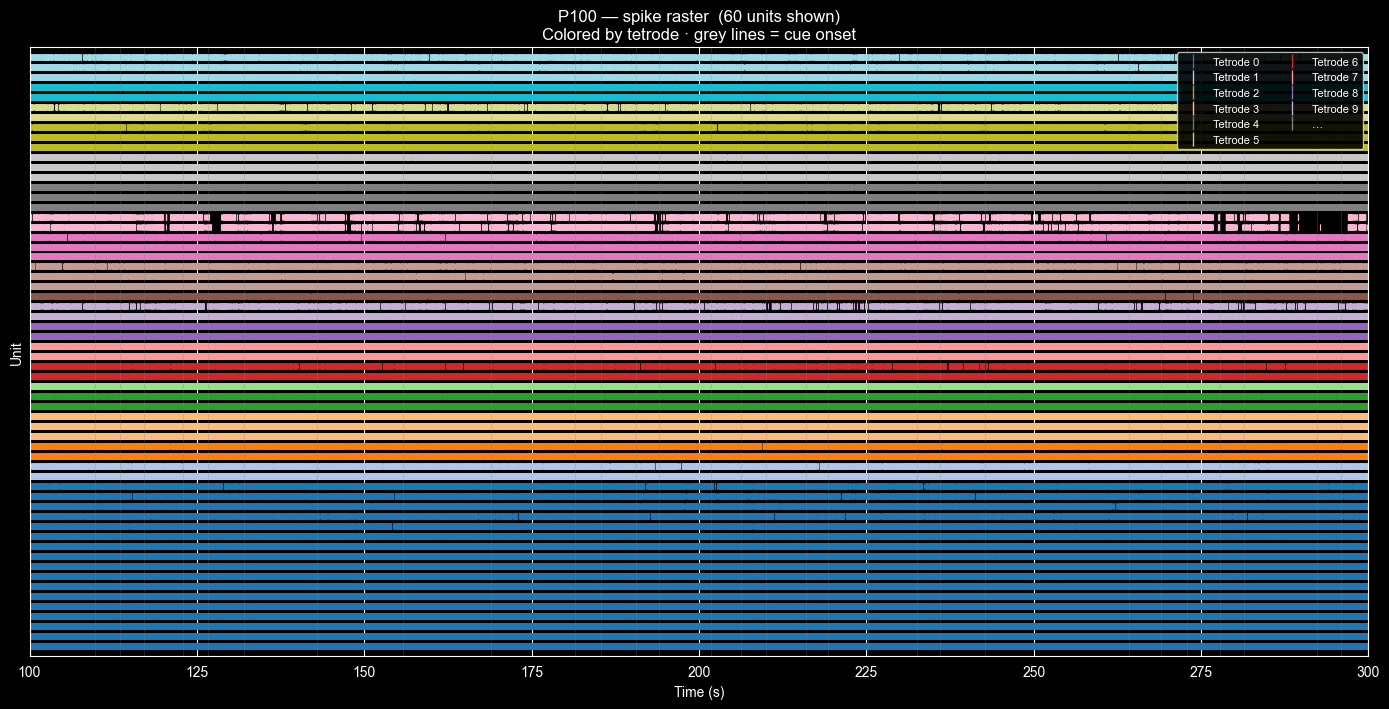

Window: 97.5 – 397.5 s  |  60 of 641 units active


In [46]:
# Spike raster — 300 s window, units sorted by tetrode, colored by tetrode
# Vertical grey lines mark cue_start (trial auditory cue onset)

import matplotlib.cm as cm
from matplotlib.lines import Line2D

# Build unit_id → tetrode_id lookup from annotation table
trode_id_map = annot_df.set_index("unit_id")["quantification"].astype(int).to_dict()

# Pick a 300 s window starting at the first valid trial
t_start = float(trials_df["start_time"].iloc[1])
t_end = t_start + 300.0

# Collect per-unit (spike times in window, tetrode ID), drop silent units
unit_rows = []
for uid, st in enumerate(spike_trains):
    in_win = st[(st >= t_start) & (st <= t_end)]
    if len(in_win) > 0:
        tid = trode_id_map.get(uid, 0)
        unit_rows.append((uid, tid, in_win))

# Sort by tetrode, then limit to 60 most active units to keep the plot readable
unit_rows.sort(key=lambda x: (x[1], -len(x[2])))
if len(unit_rows) > 60:
    unit_rows = sorted(unit_rows, key=lambda x: -len(x[2]))[:60]
    unit_rows.sort(key=lambda x: x[1])

unique_trodes_raster = sorted({t for _, t, _ in unit_rows})
cmap = cm.get_cmap("tab20", len(unique_trodes_raster))
trode_color = {t: cmap(i) for i, t in enumerate(unique_trodes_raster)}

fig, ax = plt.subplots(figsize=(14, max(4, len(unit_rows) * 0.12)))
for row_idx, (uid, tid, spikes) in enumerate(unit_rows):
    ax.scatter(
        spikes - t_start,
        np.full(len(spikes), row_idx),
        marker="|", s=25, linewidths=0.8,
        color=trode_color[tid],
    )

# Mark cue_start (auditory cue onset) within the window
cue_col = "cue_start" if "cue_start" in dati_df.columns else "tim_2"
cue_times = dati_df[cue_col].dropna()
for ct in cue_times[(cue_times >= t_start) & (cue_times <= t_end)]:
    ax.axvline(ct - t_start, color="gray", lw=0.5, alpha=0.35)

ax.set_xlabel("Time (s)")
ax.set_ylabel("Unit")
ax.set_yticks([])
ax.set_xlim(100, 300)
ax.set_ylim(-1, len(unit_rows))
ax.set_title(
    f"P100 — spike raster  ({len(unit_rows)} units shown)\n"
    "Colored by tetrode · grey lines = cue onset"
)

# Tetrode legend (cap at 10 entries to avoid clutter)
legend_trodes = unique_trodes_raster[:10]
legend_elements = [
    Line2D([0], [0], marker="|", color=trode_color[t], markersize=10, lw=0,
           label=f"Tetrode {t}")
    for t in legend_trodes
]
if len(unique_trodes_raster) > 10:
    legend_elements.append(
        Line2D([0], [0], marker="|", color="gray", markersize=10, lw=0, label="…")
    )
ax.legend(handles=legend_elements, loc="upper right", ncol=2, fontsize=8,
          framealpha=0.9)

fig.tight_layout()
plt.show()
print(f"Window: {t_start:.1f} – {t_end:.1f} s  |  {len(unit_rows)} of {len(spike_trains)} units active")

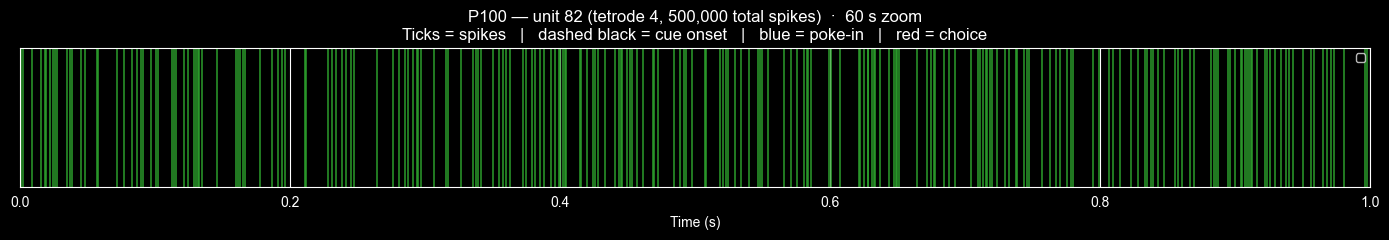

Spikes in zoom window: 234  |  Trials shown: 0


In [35]:
# Zoom in: single most-active unit over a 60 s sub-window
# Shows individual spike times alongside trial events (cue, poke-in, choice)

# Find unit with most spikes in the 300 s window
busiest = max(unit_rows, key=lambda x: len(x[2]))
best_uid, best_tid, _ = busiest

# Use a 60 s window centred on the busiest stretch of spikes
all_spikes_best = spike_trains[best_uid]
zoom_start = t_start
zoom_end = zoom_start + 1.0

# Narrow to trials fully inside the zoom window
zoom_trials = trials_df[
    (trials_df["start_time"] >= zoom_start) &
    (trials_df["stop_time"] <= zoom_end)
].copy()

spikes_zoom = all_spikes_best[
    (all_spikes_best >= zoom_start) & (all_spikes_best <= zoom_end)
]

fig, ax = plt.subplots(figsize=(14, 2.5))

# Spike ticks
ax.vlines(
    spikes_zoom - zoom_start, 0, 1,
    color=trode_color[best_tid], lw=1.2, alpha=0.9,
)

# Trial event markers
event_styles = {
    cue_col:        ("cue onset",    "black",    "--", 0.8),
    "poke_in":      ("poke in",      "steelblue", "-",  0.6),
    "choice_time":  ("choice",       "tomato",   "-",  0.6),
}
for col, (label, color, ls, alpha) in event_styles.items():
    if col not in trials_df.columns:
        continue
    times = zoom_trials[col].dropna()
    ax.vlines(
        times - zoom_start, 0, 1,
        color=color, lw=1.0, linestyle=ls, alpha=alpha, label=label,
    )

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_yticks([])
ax.set_xlabel("Time (s)")
ax.set_title(
    f"P100 — unit {best_uid} (tetrode {best_tid}, {len(all_spikes_best):,} total spikes)  ·  60 s zoom\n"
    "Ticks = spikes   |   dashed black = cue onset   |   blue = poke-in   |   red = choice"
)
ax.legend(loc="upper right", fontsize=8, framealpha=0.9)
fig.tight_layout()
plt.show()
print(f"Spikes in zoom window: {len(spikes_zoom)}  |  Trials shown: {len(zoom_trials)}")

## 9. PSTH Data (TimeSeries)

The P100 session contains a pre-computed peri-stimulus time histogram (PSTH) stored
as a `TimeSeries` in `processing["ecephys"]["rrr4_psth"]`, written by
`ProcessedTrialsInterface` during conversion.

Data shape: `(n_trials, n_units, n_bins)` — axis 0 = trial, axis 1 = unit, axis 2 = time bin.
Values are in spikes/s. Timestamps are `trial_ready` (session time of trial start);
PSTH bins are relative to `cue_start` within each trial.

Each row of `processed_trials` carries a `timeseries` reference pointing to the
corresponding row of `rrr4_psth`, so both tables stay aligned by trial index.

Three views are shown:
1. **Population average** — mean firing rate across all units and all trials
2. **All-unit heatmap** — each row is one unit, averaged across trials, sorted by peak time
3. **Single-unit trial heatmap** — individual trial responses for the most active unit,
   split by task context (frequency vs direction)

In [ ]:
# Load rrr4_psth TimeSeries from the NWB copy file
import pynwb

nwb_copy_path = SPYGLASS_RAW_DIR / ephys_copy
with pynwb.NWBHDF5IO(str(nwb_copy_path), "r", load_namespaces=True) as _io:
    _nwb = _io.read()
    psth_ts = _nwb.processing["ecephys"]["rrr4_psth"]

    # data shape: (n_trials, n_units, n_bins) — axis 0 = trial, axis 1 = unit, axis 2 = bin
    psth_data = psth_ts.data[:]          # numpy array, float32, spikes/s
    trial_ts   = psth_ts.timestamps[:]   # trial_ready timestamps (s)

# Bin parameters (from TimeSeries description — 10 ms bins, -2 to +3 s re cue onset)
bin_width_ms = 10.0
offset_s     = -2.0

n_trials, n_units, n_bins = psth_data.shape
bin_centres = offset_s + np.arange(n_bins) * bin_width_ms / 1000   # seconds re cue onset

print(f"PSTH shape : {psth_data.shape}  (trials x units x bins)")
print(f"Bin width  : {bin_width_ms:.0f} ms")
print(f"Time range : {bin_centres[0]:.2f} to {bin_centres[-1]:.2f} s (re cue onset)")
print(f"Max rate   : {psth_data.max():.1f} spikes/s")

In [ ]:
bin_centres

In [ ]:
# Quick sanity check: mean PSTH across all trials for unit 0
fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(bin_centres, psth_data[:, 0, :].mean(axis=0), color="steelblue", lw=1.8)
ax.axvline(0, color="black", lw=1, ls="--", label="cue onset")
ax.set_xlabel("Time from cue onset (s)")
ax.set_ylabel("Firing rate (spikes/s)")
ax.set_title("Unit 0 — trial-averaged PSTH")
ax.legend()
plt.show()

In [ ]:
# --- Figure 1: Population average PSTH ---
# Mean firing rate across all units and all trials
pop_mean = psth_data.mean(axis=(0, 1))              # (n_bins,)
pop_sem  = psth_data.mean(axis=0).std(axis=0) / np.sqrt(n_units)  # SEM across units

fig, ax = plt.subplots(figsize=(10, 3))
ax.fill_between(bin_centres, pop_mean - pop_sem, pop_mean + pop_sem,
                color="steelblue", alpha=0.25)
ax.plot(bin_centres, pop_mean, color="steelblue", lw=1.8, label="mean ± SEM")
ax.axvline(0, color="black", lw=1.2, ls="--", label="cue onset")
ax.axvspan(0, 0.5, color="gold", alpha=0.12, label="approx. cue window")
ax.set_xlabel("Time from cue onset (s)")
ax.set_ylabel("Firing rate (spikes/s)")
ax.set_title(f"P100 — Population average PSTH  ({n_units} units, {n_trials} trials)")
ax.legend(fontsize=9)
fig.tight_layout()
plt.show()

In [ ]:
# --- Figure 2: All-unit PSTH heatmap, sorted by peak time post-cue ---
# Each row = one unit, z-scored across time, sorted by peak bin after cue onset
unit_mean = psth_data.mean(axis=0)  # (n_units, n_bins) — mean over trials

# Z-score each unit independently so low-rate units are still visible
unit_mean_z = unit_mean - unit_mean.mean(axis=1, keepdims=True)
unit_std = unit_mean.std(axis=1, keepdims=True)
unit_mean_z = np.where(unit_std > 0, unit_mean_z / unit_std, unit_mean_z)

# Sort by peak bin in the 0–1 s post-cue window
post_cue_mask = (bin_centres >= 0) & (bin_centres <= 1.0)
peak_bins = unit_mean_z[:, post_cue_mask].argmax(axis=1)
sort_order = np.argsort(peak_bins)

fig, ax = plt.subplots(figsize=(12, 6))
im = ax.imshow(
    unit_mean_z[sort_order],
    aspect="auto",
    origin="lower",
    extent=[bin_centres[0], bin_centres[-1], 0, n_units],
    cmap="RdBu_r",
    vmin=-2, vmax=2,
)
ax.axvline(0, color="white", lw=1.0, ls="--")
ax.set_xlabel("Time from cue onset (s)")
ax.set_ylabel("Unit (sorted by peak latency)")
ax.set_title("P100 — All-unit PSTH heatmap (z-scored, sorted by peak time)")
plt.colorbar(im, ax=ax, label="Z-score", shrink=0.8)
fig.tight_layout()
plt.show()

In [ ]:
# --- Figure 3: Single-unit trial heatmap split by task context ---
# Most active unit (highest mean firing rate), trials split by task context (F vs D)

best_unit_idx = int(unit_mean.mean(axis=1).argmax())

# Get task_context for the n_trials trials from the trials_df fetched earlier
context_vals = trials_df["HistorySection_task_history"].values[:n_trials]

freq_mask = np.array([str(c).lower() in ("f", "freq", "frequency") for c in context_vals])
dir_mask  = ~freq_mask

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)
cbar_kw = dict(label="spikes/s", shrink=0.85)

for ax, mask, label, cmap in [
    (axes[0], freq_mask, "Frequency trials", "YlOrRd"),
    (axes[1], dir_mask,  "Direction trials",  "PuBu"),
]:
    # psth_data shape: (n_trials, n_units, n_bins) — index as [trial, unit, bin]
    data_subset = psth_data[mask][:, best_unit_idx, :]   # (n_mask_trials, n_bins)
    sort_by_rate = np.argsort(data_subset.mean(axis=1))[::-1]
    im = ax.imshow(
        data_subset[sort_by_rate],
        aspect="auto",
        origin="upper",
        extent=[bin_centres[0], bin_centres[-1], data_subset.shape[0], 0],
        cmap=cmap,
    )
    ax.axvline(0, color="white", lw=1.2, ls="--")
    ax.set_xlabel("Time from cue onset (s)")
    ax.set_ylabel("Trial (sorted by mean rate)")
    n_sub = mask.sum()
    ax.set_title(f"{label}  (n={n_sub})")
    plt.colorbar(im, ax=ax, **cbar_kw)

fig.suptitle(
    f"P100 — Unit {best_unit_idx} single-trial PSTH  "
    f"(mean rate {unit_mean[best_unit_idx].mean():.1f} spikes/s)",
    fontsize=12,
)
fig.tight_layout()
plt.show()

## 10. Processed Trials — ProcessedTrialsInterface (P100)

`ProcessedTrials` is a custom Spyglass table (schema `behavior_pagan`,
defined in `spyglass_extensions/spyglass_processed_trials_table.py`) that
stores a pointer to the `processed_trials` TimeIntervals table written by
`ProcessedTrialsInterface` from the `dati_*.mat` file.

The table stores a single NWB `object_id`; the actual trial data is read back
from the NWB copy file via `fetch1_dataframe()`, which returns a pandas
DataFrame with 15 behavioral columns:

| Column | Description |
|---|---|
| `start_time` / `stop_time` | Trial-ready and trial-end timestamps (dati clock, ~10 ms offset from BControl) |
| `choice` | Motor response: 0.0 = left, 1.0 = right |
| `hits` | Trial outcome: 1.0 = correct, 0.0 = incorrect |
| `nta` | Position within contextual block (1-indexed) |
| `correct_side` | "Left" or "Right" |
| `task_context` | "Direction" or "Frequency" |
| `gdir` / `gfreq` | Direction / frequency evidence log-ratio |
| `cue_start`, `poke_in`, `poke_out`, `choice_time`, `previous_trial_end` | Event timestamps (s) |
| `stim_params` | Full stimulus parameters (JSON string) |

Only populated for sessions that include a `dati_*.mat` file (P100 here; P267 does not have one).

In [40]:
from pagan_lab_to_nwb.spyglass_extensions.spyglass_processed_trials_table import ProcessedTrials

In [41]:
# One row per session that has a dati file — stores the NWB object_id pointer
(ProcessedTrials() & ephys_dict)

nwb_file_name name of the NWB file,processed_trials_object_id NWB object ID for the processed_trials TimeIntervals
sub-P100_ses-TaskSwitch4-181010a_.nwb,245bb97e-73ae-4b48-a5f7-e486030d5783


In [42]:
# fetch1_dataframe() reads the NWB copy file to resolve the stored object_id
# and returns the full processed_trials TimeIntervals as a pandas DataFrame
dati_df = (ProcessedTrials() & ephys_dict).fetch1_dataframe()

print(f"{len(dati_df)} trials,  columns: {list(dati_df.columns)}\n")
dati_df[["start_time", "stop_time", "task_context", "correct_side",
         "choice", "hits", "nta", "gdir", "gfreq", "cue_start"]].head()

780 trials,  columns: ['start_time', 'stop_time', 'choice', 'hits', 'nta', 'correct_side', 'task_context', 'gdir', 'gfreq', 'previous_trial_end', 'cue_start', 'poke_in', 'poke_out', 'choice_time', 'stim_params']



,start_time,stop_time,task_context,correct_side,choice,hits,nta,gdir,gfreq,cue_start
id,,,,,,,,,,
0,77.607827,97.477827,Direction,Right,NaN,NaN,1.0,2.5,-4.0,77.608844
1,97.497827,101.556841,Direction,Left,NaN,NaN,2.0,-4.0,-2.5,97.498832
2,101.576833,106.404836,Direction,Left,NaN,NaN,3.0,-2.5,-1.0,101.577827
3,106.424838,112.911327,Direction,Left,1.0,0.0,4.0,-1.0,-4.0,106.425827
4,112.931327,119.790327,Direction,Left,1.0,0.0,5.0,-1.0,-4.0,112.932327


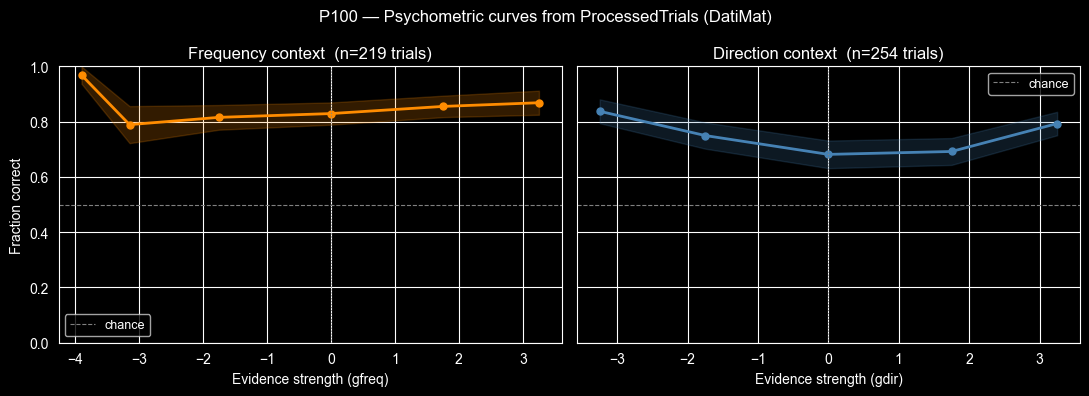

In [43]:
# Psychometric curves — correct rate vs evidence strength, split by task context
freq_trials = dati_df[dati_df["task_context"] == "Frequency"].dropna(subset=["gfreq", "hits"])
dir_trials  = dati_df[dati_df["task_context"] == "Direction"].dropna(subset=["gdir", "hits"])

def psychometric_bins(trials, x_col, n_bins=7):
    """Bin trials by evidence strength and compute mean ± SEM correct rate."""
    edges = np.percentile(trials[x_col], np.linspace(0, 100, n_bins + 1))
    edges = np.unique(edges)
    centres, means, sems = [], [], []
    for lo, hi in zip(edges[:-1], edges[1:]):
        sel = trials[(trials[x_col] >= lo) & (trials[x_col] <= hi)]["hits"]
        if len(sel) < 3:
            continue
        centres.append((lo + hi) / 2)
        means.append(sel.mean())
        sems.append(sel.sem())
    return np.array(centres), np.array(means), np.array(sems)

fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)

for ax, trials, xcol, label, color in [
    (axes[0], freq_trials, "gfreq", "Frequency context", "darkorange"),
    (axes[1], dir_trials,  "gdir",  "Direction context", "steelblue"),
]:
    xs, ms, ss = psychometric_bins(trials, xcol)
    ax.fill_between(xs, ms - ss, ms + ss, color=color, alpha=0.2)
    ax.plot(xs, ms, "o-", color=color, lw=2, ms=5)
    ax.axhline(0.5, color="gray", lw=0.8, ls="--", label="chance")
    ax.axvline(0, color="gray", lw=0.8, ls=":")
    ax.set_xlabel(f"Evidence strength ({xcol})")
    ax.set_ylabel("Fraction correct" if ax is axes[0] else "")
    ax.set_title(f"{label}  (n={len(trials)} trials)")
    ax.set_ylim(0, 1)
    ax.legend(fontsize=9)

fig.suptitle("P100 — Psychometric curves from ProcessedTrials (dati_*.mat)", fontsize=12)
fig.tight_layout()
plt.show()

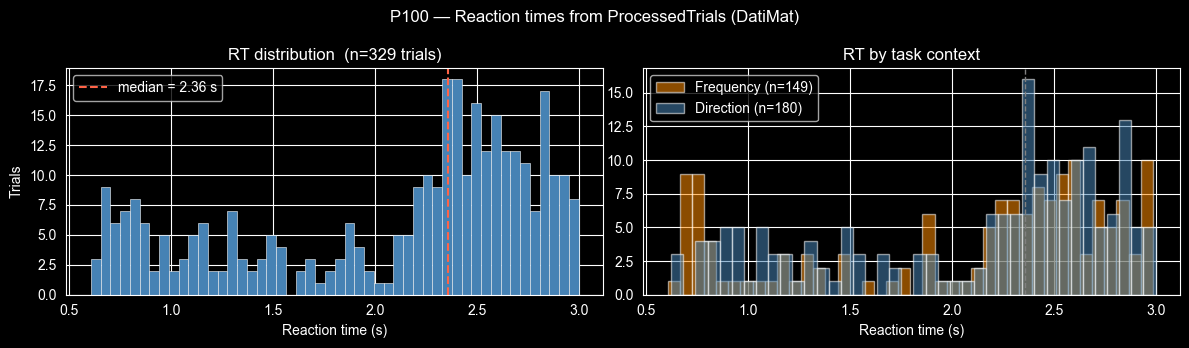

In [44]:
# Reaction time = time from cue onset to choice
dati_df["reaction_time"] = dati_df["choice_time"] - dati_df["cue_start"]
rt = dati_df["reaction_time"].dropna()
rt = rt[(rt > 0) & (rt < 3)]

fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))

# Distribution
axes[0].hist(rt, bins=50, color="steelblue", edgecolor="white", lw=0.4)
axes[0].axvline(rt.median(), color="tomato", lw=1.5, ls="--",
                label=f"median = {rt.median():.2f} s")
axes[0].set_xlabel("Reaction time (s)")
axes[0].set_ylabel("Trials")
axes[0].set_title(f"RT distribution  (n={len(rt)} trials)")
axes[0].legend()

# RT by context
for label, color in [("Frequency", "darkorange"), ("Direction", "steelblue")]:
    sel = dati_df[dati_df["task_context"] == label]["reaction_time"].dropna()
    sel = sel[(sel > 0) & (sel < 3)]
    axes[1].hist(sel, bins=40, alpha=0.55, color=color, label=f"{label} (n={len(sel)})")
axes[1].axvline(rt.median(), color="gray", lw=1, ls="--")
axes[1].set_xlabel("Reaction time (s)")
axes[1].set_title("RT by task context")
axes[1].legend()

fig.suptitle("P100 — Reaction times from ProcessedTrials (dati_*.mat)", fontsize=12)
fig.tight_layout()
plt.show()

## Summary

| Data type | Table / Access | Session |
|-----------|----------------|---------|
| NWB file registration | `sgc.Nwbfile` | Both |
| Session metadata | `sgc.Session`, `sgc.Session.Experimenter` | Both |
| Animal metadata | `sgc.Subject` | Both |
| Lab / institution | `sgc.Lab`, `sgc.Institution`, `sgc.LabMember` | Both |
| Task epochs | `TaskEpoch`, `sgc.IntervalList` | Both |
| Recording device | `sgc.DataAcquisitionDevice`, `sgc.ProbeType` | P100 |
| Electrode geometry | `sgc.ElectrodeGroup`, `sgc.Electrode` | P100 |
| Video reference | `sgc.VideoFile`, `sgc.CameraDevice` | P267 |
| Task vocabulary | `TaskRecordingTypes.{StateTypes,EventTypes,ActionTypes,Arguments}` | Both |
| Behavioral time-series | `TaskRecording.fetch1_dataframe("events"/"states"/"actions"/"trials")` | Both |
| Processed trials (dati_*.mat) | `ProcessedTrials.fetch1_dataframe()` — choice, hits, context, evidence, timestamps | P100 |
| Spike-sorted units | `ImportedSpikeSorting`, `SpikeSortingOutput`, `SortedSpikesGroup`, `UnitAnnotation` | P100 |
| PSTH (TimeSeries (rrr4_psth)) | `nwbfile.processing["ecephys"]["rrr4_psth"]` (read directly from NWB copy) | P100 |